### Import needed libraries

In [3]:
# Part 1
import pandas as pd
import numpy as np
import xgboost as xgb
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

# Part 2
import tensorflow as tf
from tensorflow import keras
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import classification_report, confusion_matrix

# Part 3
from sklearn.ensemble import RandomForestRegressor
from sklearn.model_selection import GridSearchCV

# Part 4
from sklearn.ensemble import StackingRegressor
from sklearn.linear_model import Ridge

# Part 5
import shap

# Part 6
import geopandas as gpd
import folium

### Import datasets

In [4]:

# Load datasets
df = pd.read_csv("healthcare_data.csv")



## Part 1: XGBoost Regression for Predicting Healthcare Demand based on histotical data

#### This model predicts next year's healthcare demand based on historical data.

_Model approach_

- Feature importance visualization.

- Model development

- Scatter plot of actual vs predicted cases.

- Metrics: MAE, RMSE, R² score.

- Hyperparameter tuning with GridSearchCV.

Feature 0 (f0) = District
Feature 1 (f1) = Population
Feature 2 (f2) = Healthcare_Facilities
Feature 3 (f3) = Malaria_Cases
Feature 4 (f4) = TB_Cases
Feature 5 (f5) = HIV_Cases
Feature 6 (f6) = Deaths
Feature 7 (f7) = Year



Fitting 3 folds for each of 27 candidates, totalling 81 fits
MAE: 380.62, RMSE: 449.25, R²: 0.89



<Figure size 1000x800 with 0 Axes>

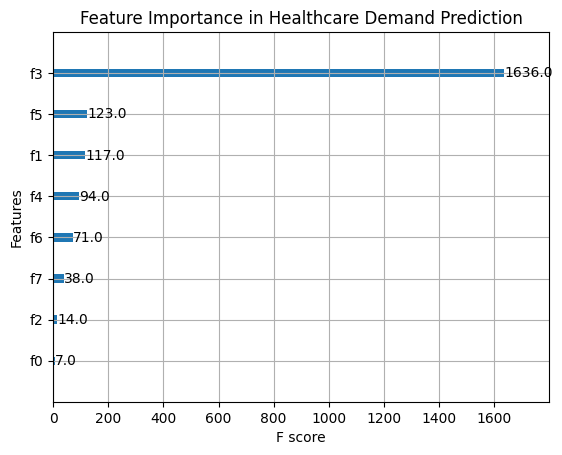

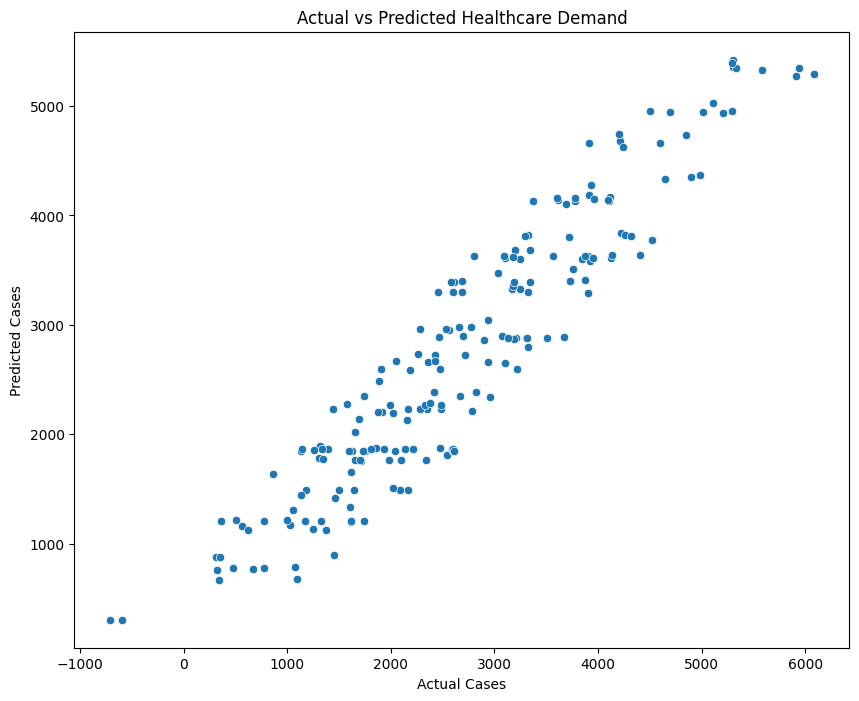

In [5]:

# Encode categorical columns
df["District"] = LabelEncoder().fit_transform(df["District"])

# Select features and target
features = ["District", "Population", "Healthcare_Facilities", "Malaria_Cases", "TB_Cases", "HIV_Cases", "Deaths", "Year"]
target = "Target_Cases"

k = 0
for i in features:
    print(f'Feature {k} (f{k}) = {i}')
    k += 1

print('\n\n')
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(df[features], df[target], test_size=0.2, random_state=42)

# Scale numerical features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Initialize XGBoost regressor
xgb_regressor = xgb.XGBRegressor(objective="reg:squarederror", random_state=42)

# Hyperparameter tuning
params = {
    "n_estimators": [100, 200, 300],
    "max_depth": [3, 5, 7],
    "learning_rate": [0.01, 0.1, 0.2]
}
grid_search = GridSearchCV(xgb_regressor, params, cv=3, scoring="r2", verbose=1, n_jobs=-1)
grid_search.fit(X_train, y_train)

# Best model
best_xgb = grid_search.best_estimator_

# Predictions
y_pred = best_xgb.predict(X_test)

# Evaluation
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print(f"MAE: {mae:.2f}, RMSE: {rmse:.2f}, R²: {r2:.2f}\n")

# Feature importance
plt.figure(figsize=(10, 8))
xgb.plot_importance(best_xgb)
plt.title("Feature Importance in Healthcare Demand Prediction")
plt.show()

# Scatter plot: Actual vs Predicted
plt.figure(figsize=(10, 8))
sns.scatterplot(x=y_test, y=y_pred)
plt.xlabel("Actual Cases")
plt.ylabel("Predicted Cases")
plt.title("Actual vs Predicted Healthcare Demand")
plt.show()


## Part 2: Neural Network for Healthcare Resource Optimization

#### This model classifies districts into High, Medium, or Low Priority based on disease burden.

_Model Approach_

- Confusion Matrix (Displaying well the model classifies High, Medium, Low priority districts).

- Model development

- Classification Report (Accuracy, Precision, Recall, F1-score).

- Training/Validation loss & accuracy curves.

C:\Users\STUDENT\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.12_qbz5n2kfra8p0\LocalCache\local-packages\Python312\site-packages\keras\src\layers\core\dense.py:87: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 18ms/step - accuracy: 0.4977 - loss: 1.0083 - val_accuracy: 0.7424 - val_loss: 0.8069
Epoch 2/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.7018 - loss: 0.7593 - val_accuracy: 0.8081 - val_loss: 0.5907
Epoch 3/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.7853 - loss: 0.5428 - val_accuracy: 0.8384 - val_loss: 0.4415
Epoch 4/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.8566 - loss: 0.3942 - val_accuracy: 0.8687 - val_loss: 0.3593
Epoch 5/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.9126 - loss: 0.3182 - val_accuracy: 0.8990 - val_loss: 0.2832
Epoch 6/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - accuracy: 0.9173 - loss: 0.2442 - val_accuracy: 0.9192 - val_loss: 0.2466
Epoch 7/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 14ms/step - accuracy: 0.9540 - loss: 0.1983 - val_accuracy: 0.9242 - val_loss: 0.2199
Epoch 8/10
50/50 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - accuracy: 0.9478 - loss: 0.1720 - val_accuracy: 0.9242 - val

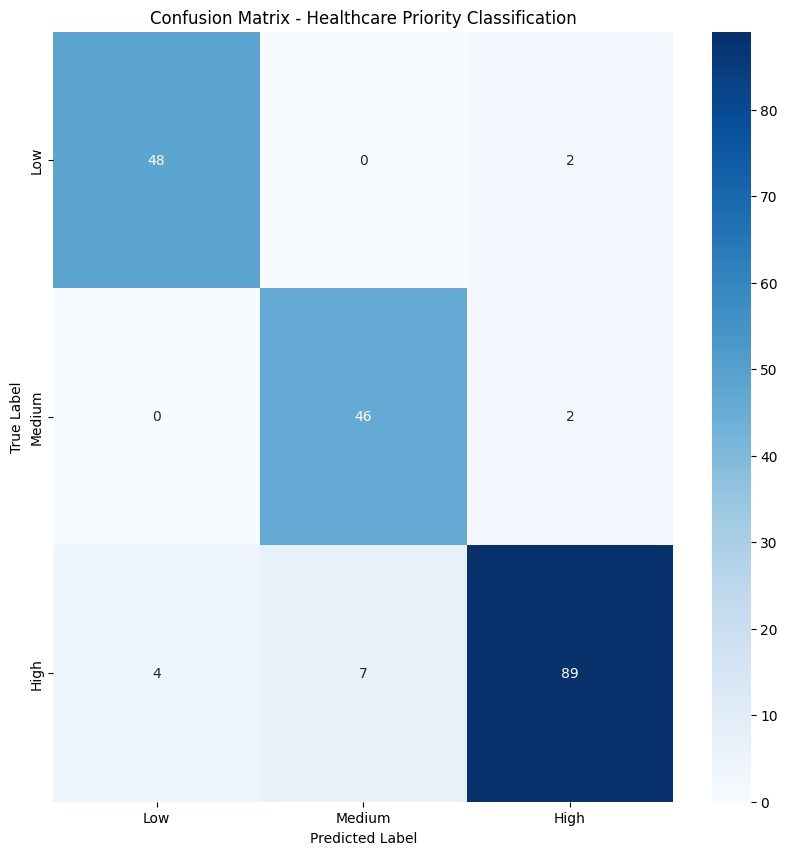

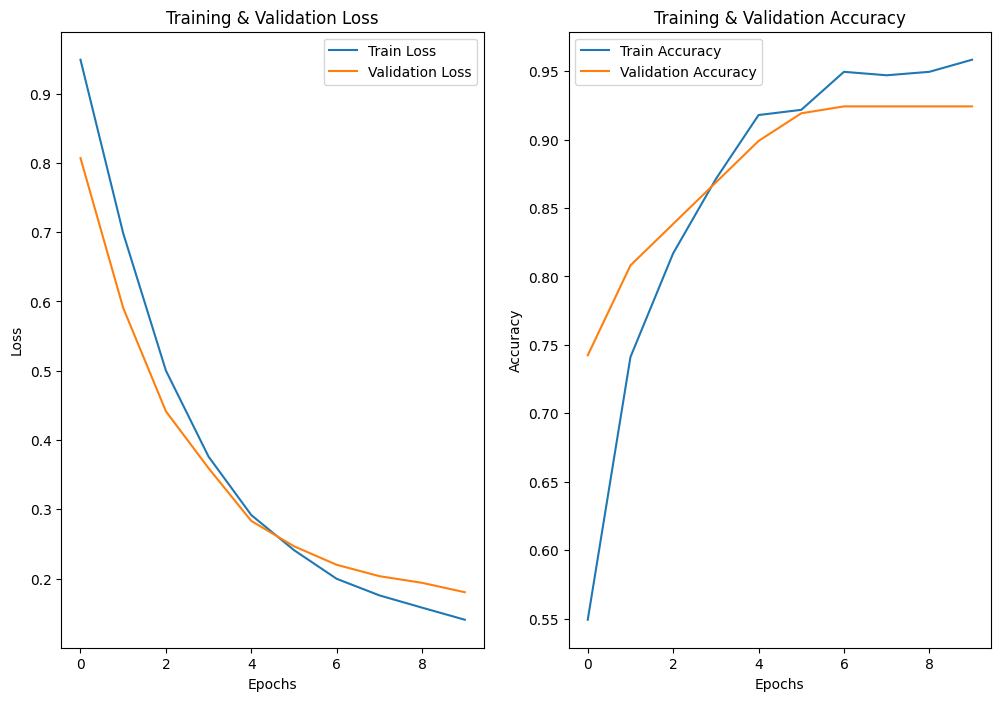

In [6]:
# Encode categorical target
encoder = OneHotEncoder(sparse_output=False)
y_encoded = encoder.fit_transform(df[["Priority_Level"]])  # Convert High, Medium, Low into one-hot encoding

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(df[features], y_encoded, test_size=0.2, random_state=42)

# Scale numerical features
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Build neural network model
model = keras.Sequential([
    keras.layers.Dense(64, activation="relu", input_shape=(X_train.shape[1],)),
    keras.layers.Dense(32, activation="relu"),
    keras.layers.Dense(3, activation="softmax")  # 3 classes (Clsifies districts into: High, Medium, Low) - according to facility needs from disease burden
])

# Compile model
model.compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])

# Train model
history = model.fit(X_train, y_train, epochs=10, batch_size=16, validation_data=(X_test, y_test), verbose=1)

# Evaluate model
y_pred_prob = model.predict(X_test)
y_pred = np.argmax(y_pred_prob, axis=1)
y_test_labels = np.argmax(y_test, axis=1)

# Classification report
print(classification_report(y_test_labels, y_pred, target_names=["Low", "Medium", "High"]))

# Confusion Matrix
conf_matrix = confusion_matrix(y_test_labels, y_pred)
plt.figure(figsize=(10,10))
sns.heatmap(conf_matrix, annot=True, fmt="d", cmap="Blues", xticklabels=["Low", "Medium", "High"], yticklabels=["Low", "Medium", "High"])
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix - Healthcare Priority Classification")
plt.show()

# Plot training loss and accuracy
plt.figure(figsize=(12, 8))
plt.subplot(1, 2, 1)
plt.plot(history.history["loss"], label="Train Loss")
plt.plot(history.history["val_loss"], label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.legend()
plt.title("Training & Validation Loss")

plt.subplot(1, 2, 2)
plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.plot(history.history["val_accuracy"], label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.legend()
plt.title("Training & Validation Accuracy")
plt.legend()
plt.show()




## Part 3: Random Forest Regression for Healthcare Demand Prediction

Fitting 3 folds for each of 81 candidates, totalling 243 fits
Random Forest - MAE: 0.00, RMSE: 0.01, R²: 1.00
Size of test: 198 - Size of prediction 198

Comparison of Models:
XGBoost  - MAE: 2757.02, R²: -13176080.33
Random Forest - MAE: 0.00, RMSE: 0.01, R²: 1.00


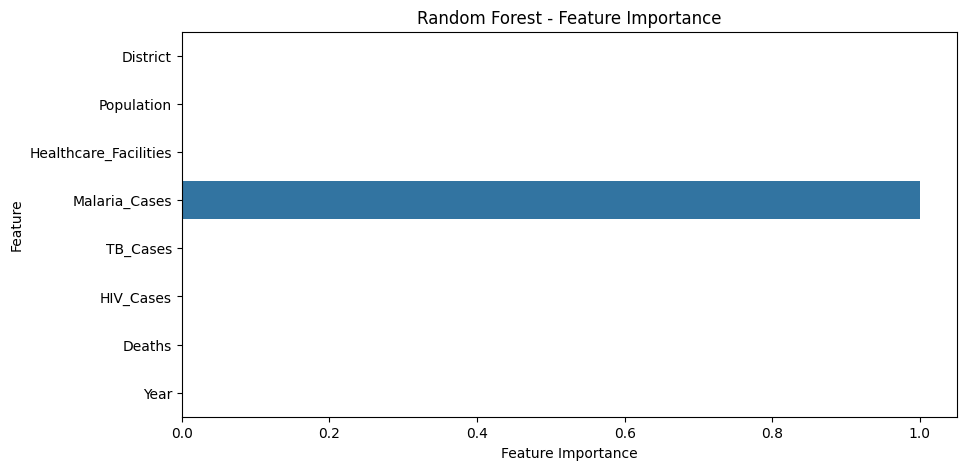

(198, 3)
(198, 3)


In [14]:
# Initialize Random Forest Regressor
rf_regressor = RandomForestRegressor(random_state=42)

# Hyperparameter tuning
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4]
}

grid_search_rf = GridSearchCV(rf_regressor, param_grid, cv=3, scoring="r2", n_jobs=-1, verbose=1)
grid_search_rf.fit(X_train, y_train)

# Best model
best_rf = grid_search_rf.best_estimator_

# Predictions
y_pred_rf = best_rf.predict(X_test)

# Evaluation Metrics
mae_rf = mean_absolute_error(y_test, y_pred_rf)
rmse_rf = np.sqrt(mean_squared_error(y_test, y_pred_rf))
r2_rf = r2_score(y_test, y_pred_rf)

print(f"Random Forest - MAE: {mae_rf:.2f}, RMSE: {rmse_rf:.2f}, R²: {r2_rf:.2f}")

# Compare with XGBoost
y_pred_xgb = best_xgb.predict(X_test)
print(f'Size of test: {y_test.shape[0]} - Size of prediction {y_pred_xgb.shape[0]}')

y_test_encoded = np.argmax(y_test, axis=1)  # Convert one-hot encoding back to labels
mae_xgb = mean_absolute_error(y_test_encoded, y_pred_xgb)
# rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test_encoded, y_pred_xgb)

print("\nComparison of Models:")
print(f"XGBoost  - MAE: {mae_xgb:.2f}, R²: {r2_xgb:.2f}")
print(f"Random Forest - MAE: {mae_rf:.2f}, RMSE: {rmse_rf:.2f}, R²: {r2_rf:.2f}")

# Feature Importance Plot
plt.figure(figsize=(10, 5))
feature_importances = best_rf.feature_importances_
sns.barplot(x=feature_importances, y=features)
plt.xlabel("Feature Importance")
plt.ylabel("Feature")
plt.title("Random Forest - Feature Importance")
plt.show()

# Scatter Plot: Actual vs Predicted (Random Forest)
y_test_encoded = np.argmax(y_test, axis=1)
print(y_test.shape)
print(y_pred_rf.shape)

# plt.figure(figsize=(8, 6))
# plt.scatter(x=y_test_encoded, y=y_pred_rf)
# plt.xlabel("Actual Cases")
# plt.ylabel("Predicted Cases")
# plt.title("Random Forest: Actual vs Predicted Healthcare Demand")
# plt.show()



## Part 4: Stacked Ensemble Model (XGBoost + Random Forest) for better healthcare demand prediction

#### Combines XGBoost and Random Forest using a meta-learner (Linear Regression) for better predictive accuracy.

In [20]:
# Define base models
base_models = [
    ('xgb', best_xgb),  # Optimized XGBoost model
    ('rf', best_rf)     # Optimized Random Forest model
]

# Meta-learner: Ridge Regression (can use other regressors)
stacked_model = StackingRegressor(estimators=base_models, final_estimator=Ridge(), cv=5)

# Train stacked model
y_train_single = y_train[:, 0]
y_test_single = y_test[:, 0]
stacked_model.fit(X_train, y_train_single)

# Predictions
y_pred_stack = stacked_model.predict(X_test)

# Evaluate ensemble model
mae_stack = mean_absolute_error(y_test_single, y_pred_stack)
rmse_stack = np.sqrt(mean_squared_error(y_test_single, y_pred_stack))
r2_stack = r2_score(y_test_single, y_pred_stack)

print(f"Stacked Model - MAE: {mae_stack:.2f}, RMSE: {rmse_stack:.2f}, R²: {r2_stack:.2f}")


Stacked Model - MAE: 0.00, RMSE: 0.01, R²: 1.00


## Part 5: SHAP for Feature Explainability 

#### - Investigating how the most influential features influnces the predictions of healthcare demands.
#### - How a specific feature (e.g., population density, disease burden) affects predictions.

Feature names: ['District', 'Population', 'Healthcare_Facilities', 'Malaria_Cases', 'TB_Cases', 'HIV_Cases', 'Deaths', 'Year']
SHAP values type: <class 'shap._explanation.Explanation'>
SHAP values shape: (198, 8)


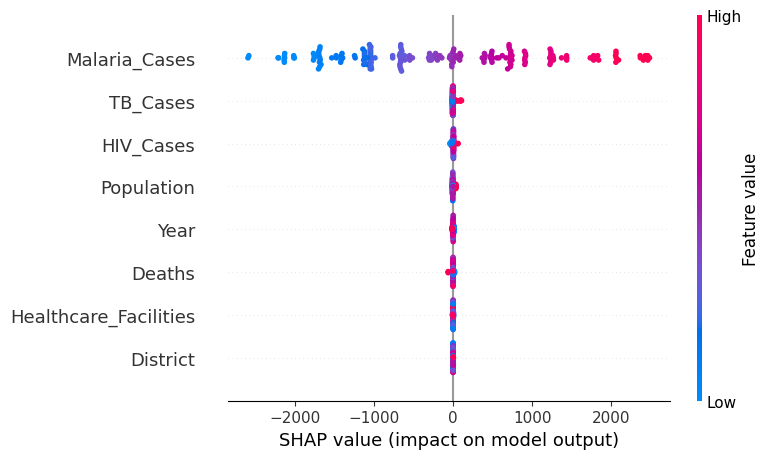

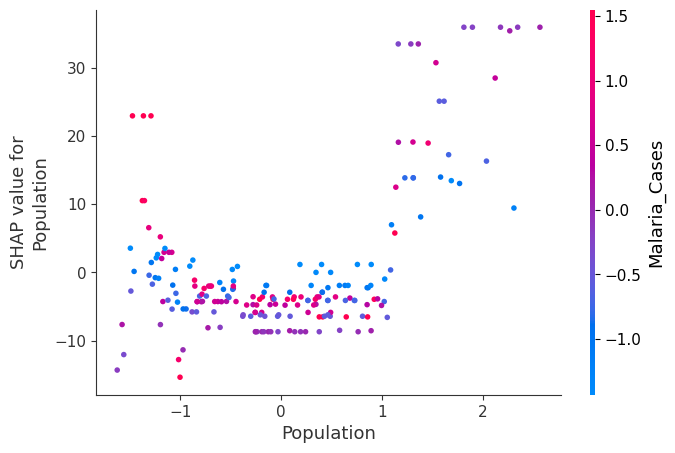

In [39]:

# Explain the XGBoost model
explainer = shap.Explainer(best_xgb)
shap_values = explainer(X_test)

# Print for debugging
print("Feature names:", features)
print("SHAP values type:", type(shap_values))
print("SHAP values shape:", shap_values.values.shape)

# Summary plot (this works because shap.summary_plot handles Explanation objects)
shap.summary_plot(shap_values, X_test, feature_names=features)

# Dependence plot for 'Population'
# Use shap_values.values instead of shap_values
shap.dependence_plot('Population', shap_values.values, X_test, feature_names=features)

## Part 6: Geospatial Analysis for Healthcare Facility Placement

#### Heatmap for Disease Cases: Highlights high-risk areas needing more healthcare resources.
#### District-Level Insights: Prioritize facility allocation based on disease burden.

In [42]:
# Load geospatial data (district boundaries)
rwanda_map = gpd.read_file("rwanda_districts.geojson")
df = pd.read_csv("healthcare_data_2.csv")

rwanda_map.head()

,objectid,code_dist,prov_code,province,province_eng,dist_code,district,source,capture,globalid,created_user,created_date,last_edited_user,last_edited_date,prov_engl,shape_Length,shape_Area,geometry
0,1,11,1,Umujyi wa Kigali,Kigali City,11,Nyarugenge,DLUP,2012,{79DEA8B0-F1F5-4BDB-ABFD-BBA8B9E75ED6},None,None,SDE,2024-03-05 12:17:38+00:00,City of Kigali,0.924370,0.010768,"MULTIPOLYGON Z (((29.98964 -1.86756 0, 29.9895..."
1,2,12,1,Umujyi wa Kigali,Kigali City,12,Gasabo,DLUP,2012,{5A2A6334-F94F-4191-9BC7-1077A5061D38},None,None,SDE,2024-03-05 12:17:38+00:00,City of Kigali,1.010862,0.034892,"MULTIPOLYGON Z (((30.14786 -1.79269 0, 30.1480..."
2,3,13,1,Umujyi wa Kigali,Kigali City,13,Kicukiro,DLUP,2012,{2F253D10-9ADC-4318-9CA0-0DF3A7D50164},None,None,SDE,2024-03-05 12:17:38+00:00,City of Kigali,0.767627,0.013577,"MULTIPOLYGON Z (((30.14789 -1.95542 0, 30.1481..."
3,4,21,2,Amajyepfo,South,21,Nyanza,Single layer,2012,{4B50C062-7024-45FB-82D6-0513EF527A49},None,None,SDE,2024-03-05 12:19:14+00:00,Southern Province,1.604870,0.054590,"MULTIPOLYGON Z (((29.95084 -2.23321 0, 29.9514..."
4,5,22,2,Amajyepfo,South,22,Gisagara,DLUP,2012,{15D1D4DC-D845-480A-9F21-098F04AC8280},None,None,SDE,2024-03-05 12:19:14+00:00,Southern Province,1.381505,0.054841,"MULTIPOLYGON Z (((29.96337 -2.43834 0, 29.9636..."


In [45]:
# Extract latitude and longitude from the geometry (centroid of each polygon)
rwanda_map["latitude"] = rwanda_map["geometry"].centroid.y
rwanda_map["longitude"] = rwanda_map["geometry"].centroid.x

# Create a Folium map centered on Rwanda
m = folium.Map(location=[-1.9403, 29.8739], zoom_start=7)

# Add CircleMarkers for disease burden (malaria cases)
for _, row in rwanda_map.iterrows():
    # Skip rows where malaria_cases is NaN (if the merge didn't find a match)
    if pd.isna(row["malaria_cases"]):
        print(f"Skipping {row['district']} due to missing malaria_cases")
        continue
    
    folium.CircleMarker(
        location=[row["latitude"], row["longitude"]],
        radius=row["malaria_cases"] / 1000,  # Adjust scaling as needed
        color="red",
        fill=True,
        fill_opacity=0.6,
        popup=f"{row['district']}: {row['malaria_cases']} cases"
    ).add_to(m)

# Save the interactive map
m.save("rwanda_healthcare_map.html")
print("Map saved as rwanda_healthcare_map.html")


C:\Users\STUDENT\AppData\Local\Temp\ipykernel_7408\2797919869.py:2: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  rwanda_map["latitude"] = rwanda_map["geometry"].centroid.y
C:\Users\STUDENT\AppData\Local\Temp\ipykernel_7408\2797919869.py:3: UserWarning: Geometry is in a geographic CRS. Results from 'centroid' are likely incorrect. Use 'GeoSeries.to_crs()' to re-project geometries to a projected CRS before this operation.

  rwanda_map["longitude"] = rwanda_map["geometry"].centroid.x


Skipping Nyamagabe due to missing malaria_cases
Skipping Gatsibo due to missing malaria_cases
Map saved as rwanda_healthcare_map.html
